# Pré-processamento persistido — MoNuSeg

**Objetivo:** executar o pré-processamento (Cellpose + RGBA + mapa de distância) **uma única vez**
e persistir os resultados em `data_source/MoNuSegPreprocessed/`, para que os notebooks de experimento
(ex.: `notebooks/experiments/experiment_3.ipynb`) carreguem os dados **já processados** do disco — sem reprocessar tudo a
cada novo experimento.

O que este notebook faz:

1. Carrega as **30 imagens oficiais de treino** e as **14 oficiais de teste** do MoNuSeg em conjuntos separados (C6);
2. Reduz tudo para a **resolução de trabalho 1000×1000** (P7 — mesma do `experiment_3`);
3. Executa o `PreprocessingPipeline` ([`CellposeStep`](src/pipeline/steps/preprocessing/cellpose_step.py) +
   [`RGBAStep`](src/pipeline/steps/preprocessing/rgba_step.py) +
   [`DistanceMapStep`](src/pipeline/steps/preprocessing/distance_map_step.py)) e persiste o resultado com o
   [`SaveResultsStep`](src/pipeline/steps/persistence/save_results_step.py);
4. Grava um `meta.json` com a configuração do run (lida pelo `experiment_3`).

Estrutura gerada em `data_source/`:

```
data_source/MoNuSegPreprocessed/
├── meta.json                      # work_size, splits, fonte da segmentação
├── train/
│   ├── image/          <id>.npy   # (1000, 1000, 3) uint8
│   ├── segmentation/   <id>.npy   # máscara do Cellpose (1000, 1000) uint8
│   ├── rgba/           <id>.npy   # (1000, 1000, 4) float32 [0, 1]
│   ├── ground_truth/   <id>.npy   # (1000, 1000) float32 {0, 1}
│   └── distance_map/   <id>.npy   # (1000, 1000) float32 [0, 1]
└── test/
    └── (mesma estrutura, 14 imagens)
```

> **Fallback:** se o Cellpose não estiver disponível (sem GPU), usamos o próprio ground truth como
> máscara de entrada — apenas para validar o fluxo de ponta a ponta (mesmo fallback do `experiment_3`).

> **Quando rodar de novo?** Somente quando o pré-processamento mudar (modelo do Cellpose,
> resolução de trabalho, novos Steps). Para rodar um novo experimento, basta abrir o
> `notebooks/experiments/experiment_3.ipynb`, que carrega estes dados do disco.

## 0. Setup

**Colab:** instale as dependências na célula abaixo. **Local:** garanta que o `.venv` esteja ativo.

In [1]:
# Robust setup: local or Colab — encontra a raiz do repositório e insere no sys.path
import sys
import os
repo_dir_name = 'cell-fuzzy-seg'

def find_repo_root(start='.'):
    p = os.path.abspath(start)
    prev = None
    while p != prev:
        if os.path.isdir(os.path.join(p, 'src')) or os.path.exists(os.path.join(p, 'pyproject.toml')) or os.path.isdir(os.path.join(p, '.git')):
            return p
        prev = p
        p = os.path.dirname(p)
    return None

if 'google.colab' in sys.modules:
    # tenta encontrar em /content, senão clona
    base = '/content'
    repo_root = find_repo_root(base) or os.path.join(base, repo_dir_name)
    if not os.path.exists(repo_root):
        get_ipython().system(f"git clone --branch feat/experiment_1 https://github.com/Pedro-io/cell-fuzzy-seg.git {repo_root}")
else:
    repo_root = find_repo_root(os.getcwd())

# fallback: usa cwd
if repo_root is None:
    repo_root = os.getcwd()

# muda para a raiz do repositório e garante que ela esteja no sys.path
try:
    os.chdir(repo_root)
except Exception:
    pass
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

print('Notebook CWD:', os.getcwd())
print('sys.path[0]:', sys.path[0])

Notebook CWD: /content/cell-fuzzy-seg
sys.path[0]: /content/cell-fuzzy-seg


In [2]:
# Instala as dependências (apenas no Colab / primeira execução)
import sys

if "google.colab" in sys.modules:
    get_ipython().system("python -m pip install -r requirements.txt -q")
else:
    print("Ambiente local: verifique se as dependências estão instaladas no .venv.")

## 1. Imports e dispositivo

In [3]:
import os
import sys
import json
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

from src.data.load.monuseg_dataset import MonusegDataset
from src.pipeline.preprocessing_pipeline import PreprocessingPipeline
from src.pipeline.steps.preprocessing.cellpose_step import CellposeStep
from src.pipeline.steps.preprocessing.rgba_step import RGBAStep
from src.pipeline.steps.preprocessing.distance_map_step import DistanceMapStep
from src.pipeline.steps.persistence.save_results_step import SaveResultsStep

print("Imports OK")

Imports OK


## 2. Leitura — treino oficial e teste oficial separados

Carregamos as **30 imagens oficiais de treino** e as **14 oficiais de teste** do MoNuSeg em conjuntos
**separados** (C6) — nada de misturar o conjunto de teste no pré-processamento do treino.

In [4]:
train_dataset = MonusegDataset(dataset_name="monuseg", config_key="monuseg_training")
test_dataset = MonusegDataset(dataset_name="monuseg", config_key="monuseg_test")
print(f"Treino (oficial): {len(train_dataset)} imagens | Teste (oficial): {len(test_dataset)} imagens")

train_samples = [train_dataset[i] for i in range(len(train_dataset))]
test_samples = [test_dataset[i] for i in range(len(test_dataset))]
print("ids de treino:", [s["id"] for s in train_samples])
print("ids de teste:", [s["id"] for s in test_samples])

2026-08-16 19:19:32.172 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:99 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations
2026-08-16 19:19:32.178 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:99 - Getting file pairs from: image_dir=data_source/MoNuSegTestData/Tissue_Images, mask_dir=data_source/MoNuSegTestData/Annotations
2026-08-16 19:19:32.179 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-08-16 19:19:32.249 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


Treino (oficial): 30 imagens | Teste (oficial): 14 imagens


2026-08-16 19:19:32.850 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5784-01Z-00-DX1.tif
2026-08-16 19:19:32.923 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-21-5784-01Z-00-DX1.xml
2026-08-16 19:19:33.333 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5786-01Z-00-DX1.tif
2026-08-16 19:19:33.409 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-21-5786-01Z-00-DX1.xml
2026-08-16 19:19:33.792 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-38-6178-01Z-00-DX1.tif
2026-08-16 19:19:33.862 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TC

ids de treino: ['TCGA-18-5592-01Z-00-DX1', 'TCGA-21-5784-01Z-00-DX1', 'TCGA-21-5786-01Z-00-DX1', 'TCGA-38-6178-01Z-00-DX1', 'TCGA-49-4488-01Z-00-DX1', 'TCGA-50-5931-01Z-00-DX1', 'TCGA-A7-A13E-01Z-00-DX1', 'TCGA-A7-A13F-01Z-00-DX1', 'TCGA-AR-A1AK-01Z-00-DX1', 'TCGA-AR-A1AS-01Z-00-DX1', 'TCGA-AY-A8YK-01A-01-TS1', 'TCGA-B0-5698-01Z-00-DX1', 'TCGA-B0-5710-01Z-00-DX1', 'TCGA-B0-5711-01Z-00-DX1', 'TCGA-CH-5767-01Z-00-DX1', 'TCGA-DK-A2I6-01A-01-TS1', 'TCGA-E2-A14V-01Z-00-DX1', 'TCGA-E2-A1B5-01Z-00-DX1', 'TCGA-G2-A2EK-01A-02-TSB', 'TCGA-G9-6336-01Z-00-DX1', 'TCGA-G9-6348-01Z-00-DX1', 'TCGA-G9-6356-01Z-00-DX1', 'TCGA-G9-6362-01Z-00-DX1', 'TCGA-G9-6363-01Z-00-DX1', 'TCGA-HE-7128-01Z-00-DX1', 'TCGA-HE-7129-01Z-00-DX1', 'TCGA-HE-7130-01Z-00-DX1', 'TCGA-KB-A93J-01A-01-TS1', 'TCGA-NH-A8F7-01A-01-TS1', 'TCGA-RD-A8N9-01A-01-TS1']
ids de teste: ['TCGA-2Z-A9J9-01A-01-TS1', 'TCGA-44-2665-01B-06-BS6', 'TCGA-69-7764-01A-01-TS1', 'TCGA-A6-6782-01A-01-BS1', 'TCGA-AC-A2FO-01A-01-TS1', 'TCGA-AO-A0J2-01A-01-BSA

## 3. Pré-processamento — Cellpose + RGBA + mapa de distância (em 1000²) + persistência

Executa a segmentação inicial (Cellpose), monta a imagem RGBA (RGB + alpha da máscara) e calcula o
**mapa de distância** a partir do ground truth — tudo na **resolução de trabalho 1000×1000** (P7).

A diferença para os notebooks de experimento: aqui o resultado é **persistido em disco** pelo
`SaveResultsStep` (que delega a gravação ao `src/io/output_writer.py`). O passo grava cada chave do
dicionário como `<output_dir>/<chave>/<id>.npy` — formato NumPy, que preserva a precisão `float32`
de `rgba` e `distance_map`.

In [5]:
WORK_SIZE = 1000  # resolução de trabalho (P7) — mesma usada pelo experiment_3

# Pasta de destino dentro de data_source/
PREPROCESSED_DIR = os.path.join("data_source", "MoNuSegPreprocessed")


def resize_sample(sample, size=WORK_SIZE):
    """Reduz imagem e ground truth para a resolução de trabalho."""
    img = sample["image"]
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    img = cv2.resize(img, (size, size))
    gt = cv2.resize(sample["ground_truth"], (size, size), interpolation=cv2.INTER_NEAREST)
    return {"id": sample["id"], "image": img, "ground_truth": gt}


train_samples = [resize_sample(s) for s in train_samples]
test_samples = [resize_sample(s) for s in test_samples]
print("Exemplo:", train_samples[0]["image"].shape, train_samples[0]["ground_truth"].shape)

# Tenta usar o Cellpose; sem GPU, usa o ground truth como máscara de entrada.
cellpose_step = None
try:
    cellpose_step = CellposeStep()
    print("Cellpose disponível — usando a segmentação inicial real.")
except Exception as e:
    print(f"[fallback] Cellpose indisponível: {e}")
    print("[fallback] Usando o ground truth como máscara de entrada (apenas para validar o fluxo).")


def build_pipeline(output_dir):
    """Monta o pipeline de pré-processamento com persistência em output_dir."""
    steps = []
    if cellpose_step is not None:
        steps.append(cellpose_step)
    steps += [RGBAStep(), DistanceMapStep(), SaveResultsStep(output_dir=output_dir)]
    return PreprocessingPipeline(steps)


def run_preprocess(sample, output_dir):
    """Pré-processa uma amostra e persiste o resultado em output_dir."""
    data = {"id": sample["id"], "image": sample["image"], "ground_truth": sample["ground_truth"]}
    if cellpose_step is None:
        data["segmentation"] = (sample["ground_truth"] > 0).astype(np.uint8)
    return build_pipeline(output_dir).run(data, verbose=False)


t0 = time.time()
train_preprocessed = [run_preprocess(s, os.path.join(PREPROCESSED_DIR, "train")) for s in train_samples]
test_preprocessed = [run_preprocess(s, os.path.join(PREPROCESSED_DIR, "test")) for s in test_samples]
print(f"Pré-processadas e persistidas: {len(train_preprocessed)} treino / {len(test_preprocessed)} teste "
      f"em {time.time() - t0:.1f}s")

# meta.json: configuração do run, lida pelo experiment_3 ao carregar os dados.
meta = {
    "work_size": WORK_SIZE,
    "segmentation_source": "cellpose" if cellpose_step is not None else "ground_truth_fallback",
    "splits": {"train": len(train_samples), "test": len(test_samples)},
    "keys": ["image", "segmentation", "rgba", "ground_truth", "distance_map"],
    "created_at": time.strftime("%Y-%m-%d %H:%M:%S"),
}
with open(os.path.join(PREPROCESSED_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print("\nmeta.json:")
print(json.dumps(meta, indent=2, ensure_ascii=False))

Exemplo: (1000, 1000, 3) (1000, 1000)


2026-08-16 19:19:51.041 | INFO     | src.pipeline.steps.preprocessing.cellpose_step:__init__:65 - [CellposeStep] Running on GPU (model=cpsam)
2026-08-16 19:19:51.042 | INFO     | src.pipeline.steps.persistence.save_results_step:__init__:68 - [SaveResultsStep] Persistindo em: data_source/MoNuSegPreprocessed/train


Cellpose disponível — usando a segmentação inicial real.


/usr/local/lib/python3.12/dist-packages/cellpose/dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
2026-08-16 19:20:00.962 | DEBUG    | src.pipeline.steps.preprocessing.rgba_step:_build_rgba:75 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)
2026-08-16 19:20:01.045 | DEBUG    | src.pipeline.steps.preprocessing.distance_map_step:forward:100 - [DistanceMapStep] Computed distance map with shape (1000, 1000)
2026-08-16 19:20:01.061 | DEBUG    | src.pipeline.steps.persistence.save_results_step:forward:91

Pré-processadas e persistidas: 30 treino / 14 teste em 520.1s

meta.json:
{
  "work_size": 1000,
  "segmentation_source": "cellpose",
  "splits": {
    "train": 30,
    "test": 14
  },
  "keys": [
    "image",
    "segmentation",
    "rgba",
    "ground_truth",
    "distance_map"
  ],
  "created_at": "2026-08-16 19:28:31"
}


## 4. Verificação — o que foi persistido

In [6]:
print("Estrutura persistida em", PREPROCESSED_DIR)
for split in ["train", "test"]:
    base = os.path.join(PREPROCESSED_DIR, split)
    for key in sorted(os.listdir(base)):
        n = len(os.listdir(os.path.join(base, key)))
        print(f"  {split}/{key}/: {n} arquivos")

print("\nArquivos totais por split:")
for split in ["train", "test"]:
    total = sum(
        len(os.listdir(os.path.join(PREPROCESSED_DIR, split, key)))
        for key in meta["keys"]
    )
    print(f"  {split}: {total} arquivos .npy")

Estrutura persistida em data_source/MoNuSegPreprocessed
  train/distance_map/: 30 arquivos
  train/ground_truth/: 30 arquivos
  train/image/: 30 arquivos
  train/rgba/: 30 arquivos
  train/segmentation/: 30 arquivos
  test/distance_map/: 14 arquivos
  test/ground_truth/: 14 arquivos
  test/image/: 14 arquivos
  test/rgba/: 14 arquivos
  test/segmentation/: 14 arquivos

Arquivos totais por split:
  train: 150 arquivos .npy
  test: 70 arquivos .npy


## 5. Reload de uma amostra persistida

Carregamos uma amostra de volta do disco e conferimos que os arrays são **idênticos** aos que
estavam em memória durante o pré-processamento (formato `.npy` preserva a precisão).

In [7]:
def load_sample(split, image_id):
    """Reconstrói o dicionário de uma amostra a partir dos arquivos persistidos."""
    base = os.path.join(PREPROCESSED_DIR, split)
    return {
        "id": image_id,
        "image": np.load(os.path.join(base, "image", f"{image_id}.npy")),
        "segmentation": np.load(os.path.join(base, "segmentation", f"{image_id}.npy")),
        "rgba": np.load(os.path.join(base, "rgba", f"{image_id}.npy")),
        "ground_truth": np.load(os.path.join(base, "ground_truth", f"{image_id}.npy")),
        "distance_map": np.load(os.path.join(base, "distance_map", f"{image_id}.npy")),
    }


sample_id = train_samples[0]["id"]
loaded = load_sample("train", sample_id)
print(f"Amostra: {sample_id}")
for k, v in loaded.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:15s} | shape={str(v.shape):20s} | dtype={v.dtype} | min={v.min():.3f} | max={v.max():.3f}")
    else:
        print(f"  {k:15s} | {v}")

# Confere igualdade exata com a amostra em memória (pré-processada).
mem = train_preprocessed[0]
for k in meta["keys"]:
    assert np.array_equal(loaded[k], mem[k]), f"'{k}' divergiu entre memória e disco!"
print("\nOK: dados persistidos idênticos aos dados em memória.")

Amostra: TCGA-18-5592-01Z-00-DX1
  id              | TCGA-18-5592-01Z-00-DX1
  image           | shape=(1000, 1000, 3)      | dtype=uint8 | min=8.000 | max=255.000
  segmentation    | shape=(1000, 1000)         | dtype=uint16 | min=0.000 | max=384.000
  rgba            | shape=(1000, 1000, 4)      | dtype=float32 | min=0.000 | max=1.000
  ground_truth    | shape=(1000, 1000)         | dtype=uint8 | min=0.000 | max=1.000
  distance_map    | shape=(1000, 1000)         | dtype=float32 | min=0.000 | max=1.000

OK: dados persistidos idênticos aos dados em memória.


## 6. Visualização das amostras persistidas

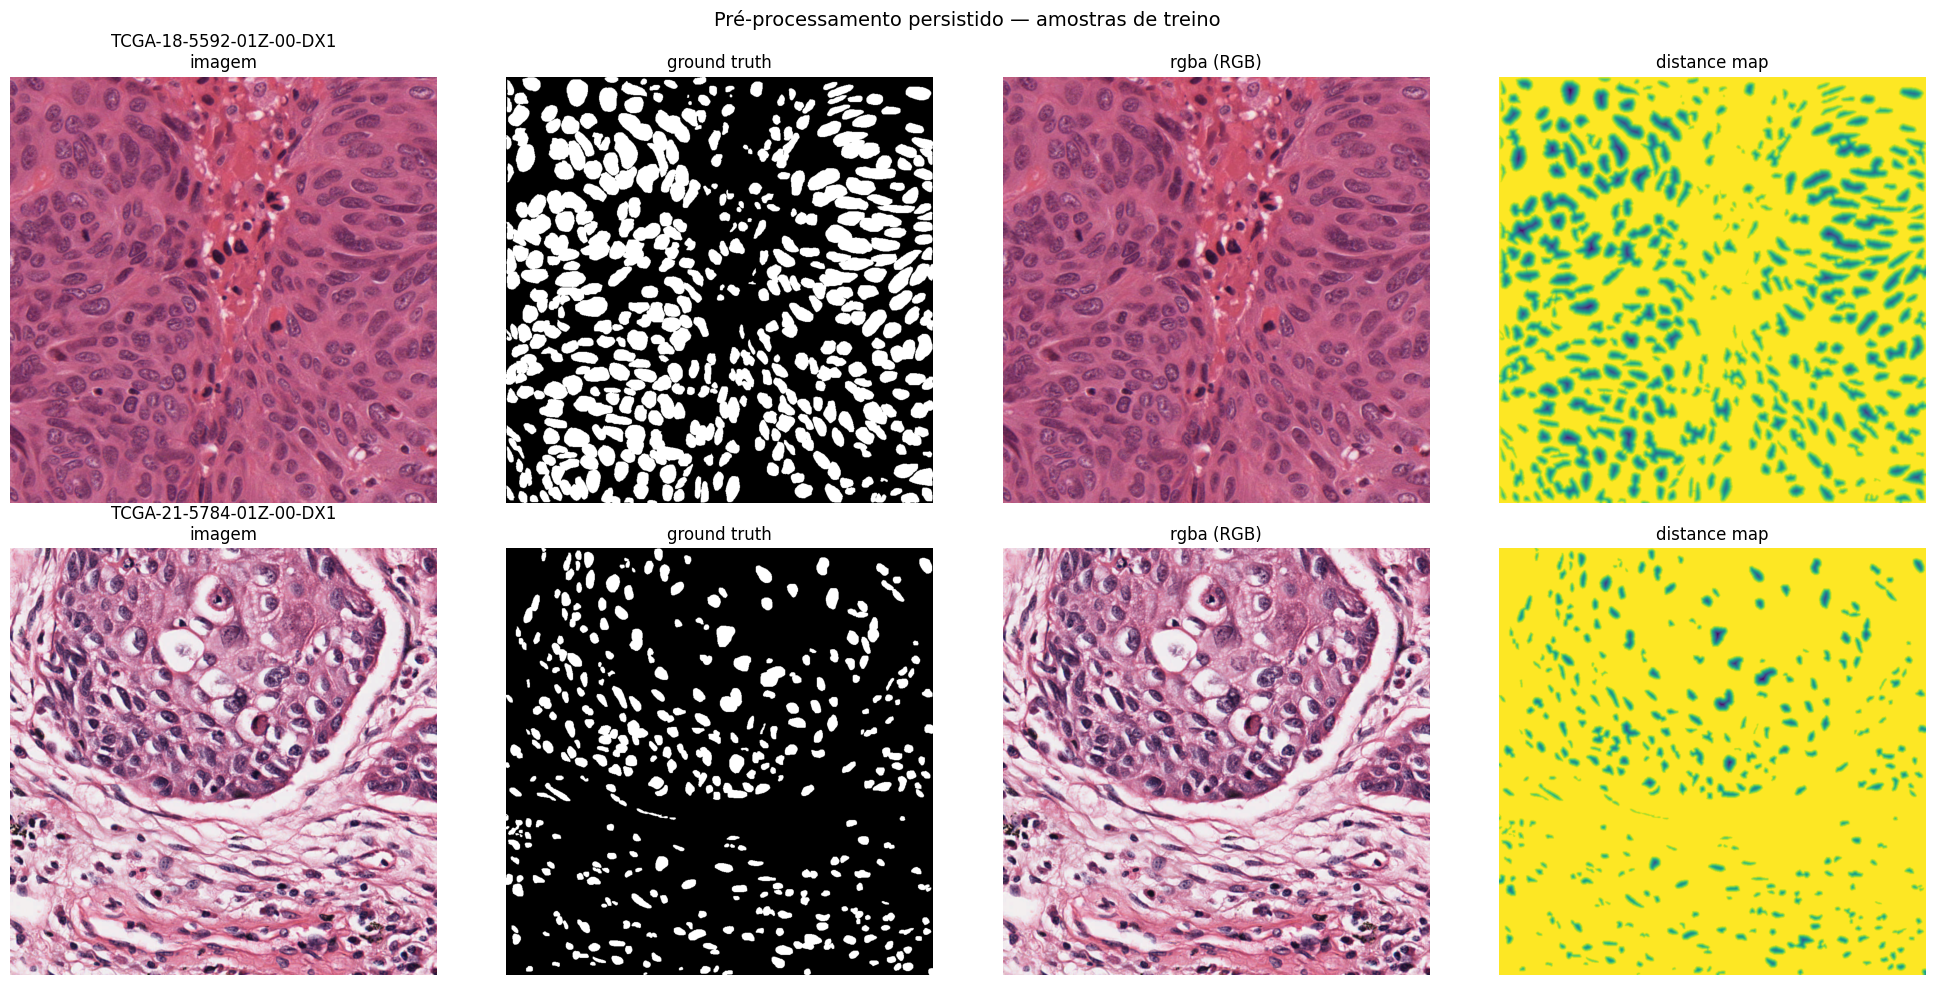

In [8]:
N = min(2, len(train_samples))
fig, axes = plt.subplots(N, 4, figsize=(20, 5 * N))
if N == 1:
    axes = axes[None, :]

for row in range(N):
    s = train_preprocessed[row]

    img = s["image"]
    if img.max() > 1.0:
        img = img.astype(np.float32) / 255.0

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{s['id']}\nimagem")
    axes[row, 1].imshow(s["ground_truth"], cmap="gray")
    axes[row, 1].set_title("ground truth")
    axes[row, 2].imshow(s["rgba"][..., :3])
    axes[row, 2].set_title("rgba (RGB)")
    axes[row, 3].imshow(s["distance_map"], cmap="viridis")
    axes[row, 3].set_title("distance map")

    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Pré-processamento persistido — amostras de treino", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Resumo e próximos passos

### O que foi feito

| Etapa | O que acontece | Onde fica |
|-------|----------------|-----------|
| **1. MonusegDataset** | Carrega imagem + anotação XML (30 treino / 14 teste) | `data_source/MoNuSeg{Training,Test}Data` |
| **2. resize** | Reduz imagem e GT para 1000×1000 (P7) | em memória |
| **3. CellposeStep** | Segmentação inicial (ou fallback com GT) | `segmentation/` |
| **4. RGBAStep** | RGB + alpha da segmentação | `rgba/` |
| **5. DistanceMapStep** | Mapa de distância sobre o GT já redimensionado | `distance_map/` |
| **6. SaveResultsStep** | Persiste tudo como `.npy` via `OutputWriter` | `data_source/MoNuSegPreprocessed/` |

### Próximos passos

1. **Rodar um experimento:** abra o `notebooks/experiments/experiment_3.ipynb` — ele carrega estes dados do disco
   (lendo `meta.json` para `WORK_SIZE`) e monta os batches sem reprocessar nada.
2. **Refazer o pré-processamento:** somente quando a configuração mudar (modelo do Cellpose,
   resolução de trabalho, novos Steps). Depois de refazer, rode o `experiment_3` novamente para
   carregar a versão nova.

> O `SaveResultsStep` pertence exclusivamente ao `PreprocessingPipeline` (regra 10 da arquitetura) —
> ele nunca participa do `TrainingPipeline`.